In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/upi_clean_data.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

df.head()

Matplotlib is building the font cache; this may take a moment.


,banks_live,txn_volume_mn,txn_value_cr,date,year,month,month_name
0,462.0,8131.87,1234098.540,2023-01-01,2023,1,Jan
1,471.0,8333.87,1326153.020,2023-02-01,2023,2,Feb
2,480.0,8744.60,1434064.800,2023-03-01,2023,3,Mar
3,487.0,9003.36,1420546.985,2023-04-01,2023,4,Apr
4,493.0,9092.98,1407029.170,2023-05-01,2023,5,May


In [2]:
# Average transaction value = total value / total volume (both scaled to same unit: Cr / Mn = Rs per txn * 100)
df["avg_txn_value_rs"] = (df["txn_value_cr"] * 1e7) / (df["txn_volume_mn"] * 1e6)

# Month-over-Month growth %
df["volume_mom_%"] = df["txn_volume_mn"].pct_change() * 100
df["value_mom_%"] = df["txn_value_cr"].pct_change() * 100

# Year-over-Year growth % (compare to same month, 12 rows earlier)
df["volume_yoy_%"] = df["txn_volume_mn"].pct_change(periods=12) * 100
df["value_yoy_%"] = df["txn_value_cr"].pct_change(periods=12) * 100

# Quarter for grouping
df["quarter"] = df["date"].dt.to_period("Q").astype(str)

# Growth category — simple rule-based bucketing (explain your thresholds in the report)
def growth_bucket(x):
    if pd.isna(x):
        return "N/A"
    elif x >= 3:
        return "High"
    elif x >= 0:
        return "Medium"
    else:
        return "Low"

df["growth_category"] = df["volume_mom_%"].apply(growth_bucket)

df.head(15)

,banks_live,txn_volume_mn,txn_value_cr,date,year,month,month_name,avg_txn_value_rs,volume_mom_%,value_mom_%,volume_yoy_%,value_yoy_%,quarter,growth_category
0,462.0,8131.87,1234098.540,2023-01-01,2023,1,Jan,1517.607315,NaN,NaN,NaN,NaN,2023Q1,N/A
1,471.0,8333.87,1326153.020,2023-02-01,2023,2,Feb,1591.281145,2.484053,7.459249,NaN,NaN,2023Q1,Medium
2,480.0,8744.60,1434064.800,2023-03-01,2023,3,Mar,1639.943279,4.928443,8.137204,NaN,NaN,2023Q1,High
3,487.0,9003.36,1420546.985,2023-04-01,2023,4,Apr,1577.796495,2.959083,-0.942622,NaN,NaN,2023Q2,Medium
4,493.0,9092.98,1407029.170,2023-05-01,2023,5,May,1547.379594,0.995406,-0.951592,NaN,NaN,2023Q2,Medium
5,502.0,9251.25,1439308.250,2023-06-01,2023,6,Jun,1555.798676,1.740573,2.294130,NaN,NaN,2023Q2,Medium
6,510.0,9608.23,1500042.740,2023-07-01,2023,7,Jul,1561.206112,3.858722,4.219700,NaN,NaN,2023Q3,High
7,519.0,10209.03,1600538.730,2023-08-01,2023,8,Aug,1567.767682,6.252973,6.699542,NaN,NaN,2023Q3,High
8,529.0,10491.27,1682987.940,2023-09-01,2023,9,Sep,1604.179418,2.764611,5.151341,NaN,NaN,2023Q3,Medium
9,538.0,11220.87,1684642.080,2023-10-01,2023,10,Oct,1501.347115,6.954353,0.098286,NaN,NaN,2023Q4,High


In [3]:
n_years = (df["date"].max() - df["date"].min()).days / 365.25
start_val = df["txn_volume_mn"].iloc[0]
end_val = df["txn_volume_mn"].iloc[-1]

cagr = ((end_val / start_val) ** (1 / n_years) - 1) * 100
print(f"Approx. UPI Volume CAGR: {cagr:.2f}% per year")

Approx. UPI Volume CAGR: 38.78% per year


In [4]:
# Peak and lowest transaction months
peak_month = df.loc[df["txn_volume_mn"].idxmax(), ["date","txn_volume_mn"]]
low_month  = df.loc[df["txn_volume_mn"].idxmin(), ["date","txn_volume_mn"]]
print("Peak month:\n", peak_month)
print("Lowest month:\n", low_month)

# Is value growing faster than volume?
print("\nAvg MoM volume growth:", df["volume_mom_%"].mean().round(2), "%")
print("Avg MoM value growth:", df["value_mom_%"].mean().round(2), "%")

# Correlation: banks live vs transaction volume
print("\nCorrelation matrix:")
print(df[["banks_live","txn_volume_mn","txn_value_cr"]].corr())

Peak month:
 date             2026-03-01 00:00:00
txn_volume_mn               22921.56
Name: 38, dtype: object
Lowest month:
 date             2023-01-01 00:00:00
txn_volume_mn                8131.87
Name: 0, dtype: object

Avg MoM volume growth: 2.83 %
Avg MoM value growth: 2.57 %

Correlation matrix:
               banks_live  txn_volume_mn  txn_value_cr
banks_live       1.000000       0.980318      0.947688
txn_volume_mn    0.980318       1.000000      0.964361
txn_value_cr     0.947688       0.964361      1.000000


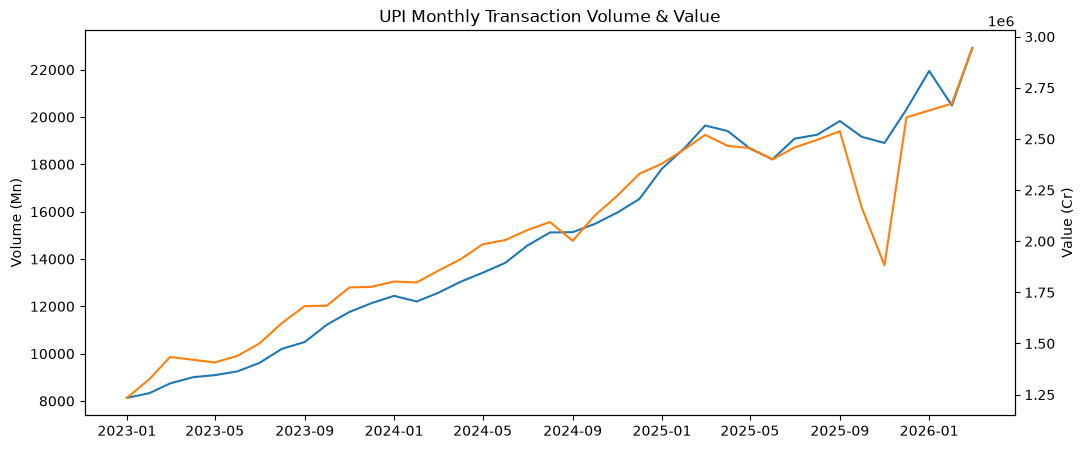

In [5]:
fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(df["date"], df["txn_volume_mn"], color="tab:blue", label="Volume (Mn)")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["txn_value_cr"], color="tab:orange", label="Value (Cr)")
ax1.set_ylabel("Volume (Mn)"); ax2.set_ylabel("Value (Cr)")
plt.title("UPI Monthly Transaction Volume & Value")
plt.show()

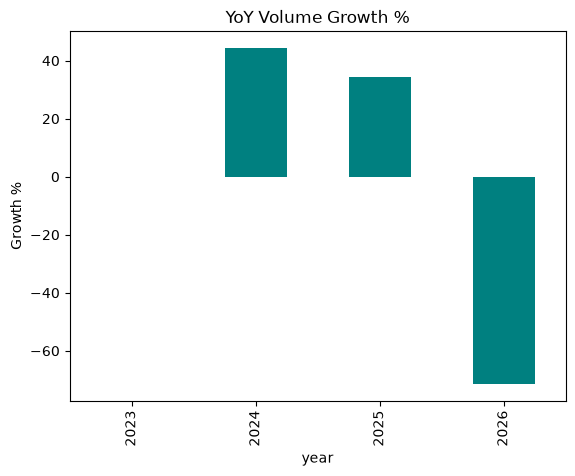

In [6]:
yearly = df.groupby("year")["txn_volume_mn"].sum()
yearly.pct_change().mul(100).plot(kind="bar", title="YoY Volume Growth %", color="teal")
plt.ylabel("Growth %")
plt.show()

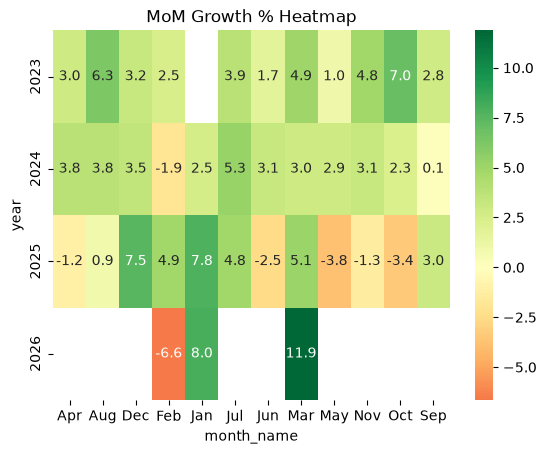

In [7]:
pivot = df.pivot_table(index="year", columns="month_name", values="volume_mom_%")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.title("MoM Growth % Heatmap")
plt.show()

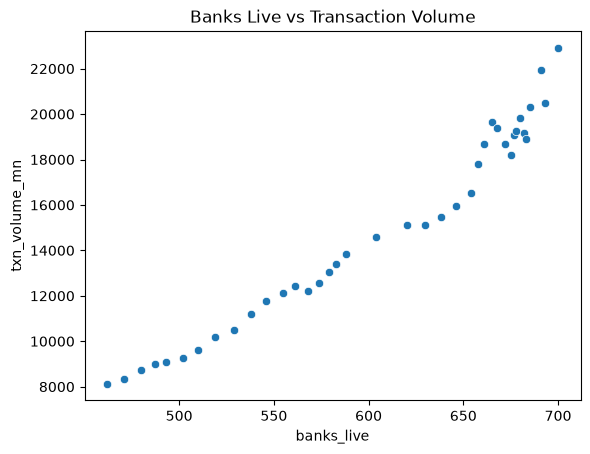

In [8]:
sns.scatterplot(data=df, x="banks_live", y="txn_volume_mn")
plt.title("Banks Live vs Transaction Volume")
plt.show()

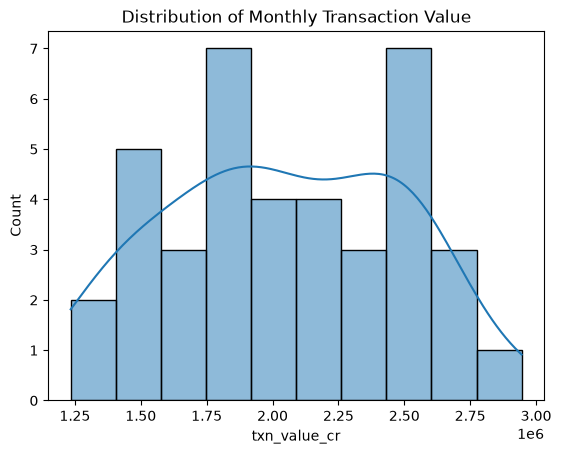

In [9]:
sns.histplot(df["txn_value_cr"], bins=10, kde=True)
plt.title("Distribution of Monthly Transaction Value")
plt.show()

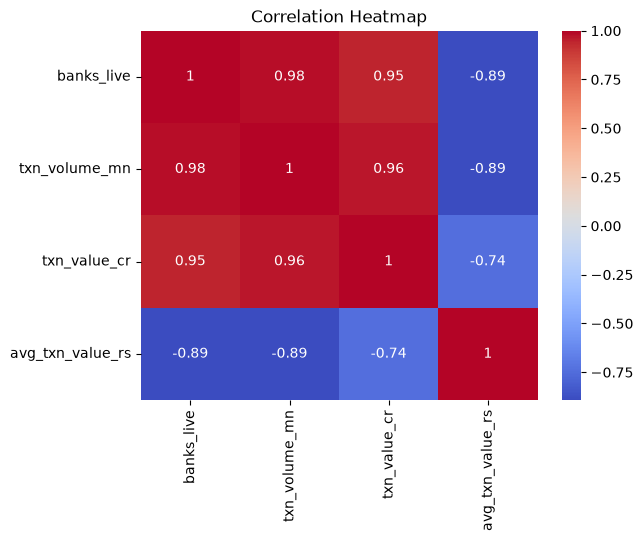

In [10]:
sns.heatmap(df[["banks_live","txn_volume_mn","txn_value_cr","avg_txn_value_rs"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df.to_csv("../data/upi_features.csv", index=False)
print("Saved:", df.shape)

Saved: (39, 14)
